# EasyRoute — Logística de reparto en Santa Cruz de la Sierra
### Espacio de estados y búsqueda (BFS vs DFS) sobre un grafo real trazado a mano

Actividad 1 · Inteligencia Artificial I (SIS-0341) · UPDS Santa Cruz

El grafo (nodos = intersecciones reales, aristas = calles reales trazadas sobre el mapa)
se construye con el editor `viz/editor.html` y se guarda en `data/manual_graph.json`.
Este notebook lee ese archivo, formaliza el espacio de estados, implementa BFS y DFS,
los compara, y exporta los resultados para la visualización interactiva.


In [11]:
import json
import math
import os
import time
import networkx as nx
import matplotlib.pyplot as plt


## 1. Carga del grafo real (armado a mano con el editor)

`data/manual_graph.json` contiene los nodos (intersecciones reales, con nombre y coordenadas) y las aristas (calles reales, trazadas punto por punto sobre el mapa) que el equipo definió con `viz/editor.html`. El costo de cada arista es la distancia real (metros) de la calle trazada, no una línea recta.

In [12]:
GRAPH_PATH = os.path.join("..", "data", "manual_graph.json")

if not os.path.exists(GRAPH_PATH):
    raise FileNotFoundError(
        "No se encontró data/manual_graph.json. Abran viz/editor.html, tracen los nodos "
        "y calles reales de Santa Cruz, y usen 'Guardar archivo' para generarlo antes de "
        "correr este notebook."
    )

with open(GRAPH_PATH, "r", encoding="utf-8") as f:
    manual_graph = json.load(f)

raw_nodes = manual_graph["nodes"]
raw_edges = manual_graph["edges"]
print(f"Nodos cargados: {len(raw_nodes)}  |  Calles cargadas: {len(raw_edges)}")

Nodos cargados: 69  |  Calles cargadas: 100


## 2. Construcción del grafo (NetworkX)

Cada nodo es una intersección real (colocada a mano sobre el mapa). Cada arista guarda también la polilínea real trazada (`points`), que se usa más adelante para dibujar el camino final siguiendo la calle de verdad, no una línea recta entre nodos.

In [13]:
def haversine_m(a, b):
    R = 6371000.0
    lat1, lon1 = math.radians(a[0]), math.radians(a[1])
    lat2, lon2 = math.radians(b[0]), math.radians(b[1])
    dlat, dlon = lat2 - lat1, lon2 - lon1
    h = math.sin(dlat / 2) ** 2 + math.cos(lat1) * math.cos(lat2) * math.sin(dlon / 2) ** 2
    return 2 * R * math.asin(math.sqrt(h))


G = nx.Graph()
for n in raw_nodes:
    G.add_node(n["id"], name=n["name"], lat=n["lat"], lon=n["lon"])

for e in raw_edges:
    points = e.get("points") or [[G.nodes[e["source"]]["lat"], G.nodes[e["source"]]["lon"]],
                                  [G.nodes[e["target"]]["lat"], G.nodes[e["target"]]["lon"]]]
    cost = e.get("cost")
    if cost is None:
        cost = sum(haversine_m(points[i], points[i + 1]) for i in range(len(points) - 1))
    G.add_edge(e["source"], e["target"], weight=cost, points=points)

if not nx.is_connected(G):
    comps = list(nx.connected_components(G))
    print(f"AVISO: el grafo tiene {len(comps)} componentes desconectados: {[len(c) for c in comps]}")
    print("Revisen en el editor que todos los nodos tengan al menos una calle que los conecte al resto.")
else:
    print(f"Grafo: {G.number_of_nodes()} nodos, {G.number_of_edges()} aristas — conexo: True")

Grafo: 69 nodos, 100 aristas — conexo: True


Deposito Central: m25 Nodo 25
Cliente Ejemplo : m66 Nodo 66
(Para fijarlos a mano, nombren un nodo con 'Depósito' o 'Cliente' en el editor,
 o reasignen DEPOSITO_ID / CLIENTE_ID manualmente en esta celda.)


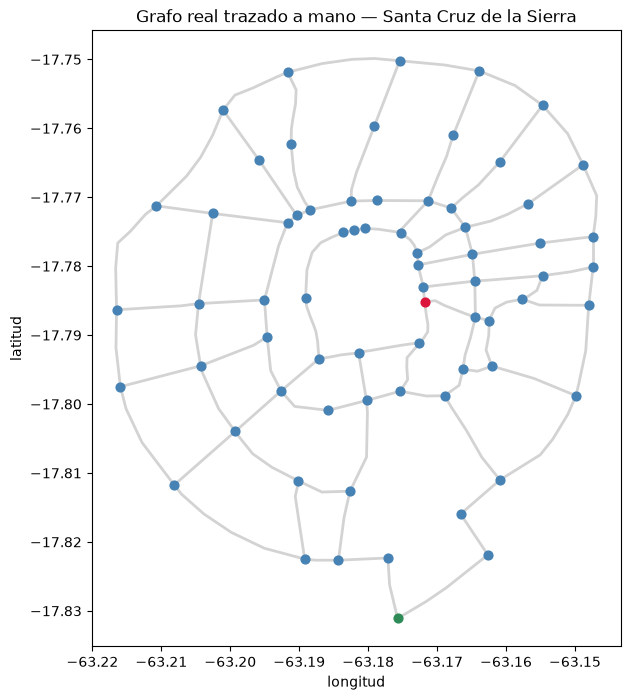

In [14]:
def pick_role_node(candidates_kw, fallback_fn):
    for nid, d in G.nodes(data=True):
        if any(kw.lower() in d["name"].lower() for kw in candidates_kw):
            return nid
    return fallback_fn()

def centroid():
    lat = sum(d["lat"] for _, d in G.nodes(data=True)) / G.number_of_nodes()
    lon = sum(d["lon"] for _, d in G.nodes(data=True)) / G.number_of_nodes()
    return (lat, lon)

_c = centroid()
DEPOSITO_ID = pick_role_node(
    ["deposito", "depósito"],
    lambda: min(G.nodes, key=lambda nid: haversine_m(_c, (G.nodes[nid]["lat"], G.nodes[nid]["lon"]))),
)
CLIENTE_ID = pick_role_node(
    ["cliente"],
    lambda: max(G.nodes, key=lambda nid: haversine_m(_c, (G.nodes[nid]["lat"], G.nodes[nid]["lon"]))),
)

print("Deposito Central:", DEPOSITO_ID, G.nodes[DEPOSITO_ID]["name"])
print("Cliente Ejemplo :", CLIENTE_ID, G.nodes[CLIENTE_ID]["name"])
print("(Para fijarlos a mano, nombren un nodo con 'Depósito' o 'Cliente' en el editor,")
print(" o reasignen DEPOSITO_ID / CLIENTE_ID manualmente en esta celda.)")

fig, ax = plt.subplots(figsize=(8, 8))
for a, b, d in G.edges(data=True):
    pts = d["points"]
    xs = [p[1] for p in pts]
    ys = [p[0] for p in pts]
    ax.plot(xs, ys, color="lightgray", linewidth=2, zorder=1)
for nid, d in G.nodes(data=True):
    color = "crimson" if nid == DEPOSITO_ID else ("seagreen" if nid == CLIENTE_ID else "steelblue")
    ax.scatter(d["lon"], d["lat"], color=color, s=40, zorder=2)
ax.set_title("Grafo real trazado a mano — Santa Cruz de la Sierra")
ax.set_xlabel("longitud")
ax.set_ylabel("latitud")
ax.set_aspect("equal")
plt.show()

## 3. Formalización como espacio de estados

- **Estado**: el nodo (intersección) donde se encuentra el vehículo de reparto.
- **Estado inicial**: `DEPOSITO_ID` (parámetro configurable, cualquier nodo puede ser inicio).
- **Estado meta**: `CLIENTE_ID` (parámetro configurable, cualquier nodo puede ser meta).
- **Operadores**: moverse a un nodo adyacente a través de una arista real (calle) del grafo.
- **Función de costo**: distancia real acumulada (metros) de las calles trazadas y recorridas.

Entorno: observable (el grafo es conocido de antemano), determinista (moverse a un nodo vecino siempre tiene el mismo resultado), estático (el grafo no cambia durante la búsqueda), secuencial (cada decisión afecta las siguientes).

In [15]:
def path_cost(G, path):
    return sum(G[path[i]][path[i + 1]]["weight"] for i in range(len(path) - 1))

## 4. Implementación de BFS y DFS

Ambos algoritmos son de **búsqueda no informada**: no usan el peso de las aristas para decidir hacia dónde expandirse (a diferencia de Dijkstra/A*). BFS explora por niveles (garantiza el camino con menor número de saltos); DFS explora en profundidad primero. El costo real del camino encontrado se calcula después, sumando las distancias reales de las calles recorridas.

In [16]:
def bfs(G, start, goal):
    t0 = time.perf_counter()
    visited = {start}
    order = [start]
    parent = {start: None}
    queue = [start]
    qi = 0
    found = start == goal
    while qi < len(queue) and not found:
        cur = queue[qi]
        qi += 1
        for nb in sorted(G.neighbors(cur)):
            if nb not in visited:
                visited.add(nb)
                parent[nb] = cur
                order.append(nb)
                queue.append(nb)
                if nb == goal:
                    found = True
                    break
    elapsed = time.perf_counter() - t0

    if goal not in parent:
        return {"path": None, "cost": None, "order": order, "nodes_explored": len(order), "time_s": elapsed}

    path = []
    node = goal
    while node is not None:
        path.append(node)
        node = parent[node]
    path.reverse()
    return {"path": path, "cost": path_cost(G, path), "order": order, "nodes_explored": len(order), "time_s": elapsed}


def dfs(G, start, goal):
    t0 = time.perf_counter()
    visited = set()
    order = []
    parent = {start: None}
    stack = [start]
    found = False
    while stack and not found:
        cur = stack.pop()
        if cur in visited:
            continue
        visited.add(cur)
        order.append(cur)
        if cur == goal:
            found = True
            break
        for nb in sorted(G.neighbors(cur), reverse=True):
            if nb not in visited:
                parent.setdefault(nb, cur)
                stack.append(nb)
    elapsed = time.perf_counter() - t0

    if goal not in visited:
        return {"path": None, "cost": None, "order": order, "nodes_explored": len(order), "time_s": elapsed}

    path = []
    node = goal
    while node is not None:
        path.append(node)
        node = parent[node]
    path.reverse()
    return {"path": path, "cost": path_cost(G, path), "order": order, "nodes_explored": len(order), "time_s": elapsed}

In [17]:
bfs_res = bfs(G, DEPOSITO_ID, CLIENTE_ID)
dfs_res = dfs(G, DEPOSITO_ID, CLIENTE_ID)

print("=== Ejemplo: Deposito Central -> Cliente Ejemplo ===")
print(f"BFS: camino de {len(bfs_res['path'])} nodos, costo {bfs_res['cost']:.0f} m, "
      f"{bfs_res['nodes_explored']} nodos explorados, {bfs_res['time_s']*1e6:.1f} us")
print("     ", " -> ".join(bfs_res["path"]))
print(f"DFS: camino de {len(dfs_res['path'])} nodos, costo {dfs_res['cost']:.0f} m, "
      f"{dfs_res['nodes_explored']} nodos explorados, {dfs_res['time_s']*1e6:.1f} us")
print("     ", " -> ".join(dfs_res["path"]))

=== Ejemplo: Deposito Central -> Cliente Ejemplo ===
BFS: camino de 8 nodos, costo 7174 m, 53 nodos explorados, 53.8 us
      m25 -> m11 -> m12 -> m45 -> m63 -> m64 -> m65 -> m66
DFS: camino de 21 nodos, costo 14988 m, 62 nodos explorados, 56.7 us
      m25 -> m11 -> m10 -> m09 -> m08 -> m07 -> m06 -> m05 -> m04 -> m03 -> m02 -> m01 -> m00 -> m17 -> m16 -> m30 -> m49 -> m48 -> m47 -> m67 -> m66


## 5. Precómputo de todos los pares (para la demo interactiva)

Se corre BFS y DFS entre **todas las combinaciones posibles** de origen/destino del grafo. Esto permite que la visualización Leaflet deje elegir cualquier par de nodos por click, sin tener que recalcular nada en el navegador. El tiempo se mide con varias repeticiones para reducir ruido de medición.

In [18]:
NODE_IDS = list(G.nodes())
REPS = 30

all_pairs = {}
t_start = time.perf_counter()
for start in NODE_IDS:
    for goal in NODE_IDS:
        if start == goal:
            continue
        bfs_trace = bfs(G, start, goal)
        dfs_trace = dfs(G, start, goal)

        bfs_times = [bfs(G, start, goal)["time_s"] for _ in range(REPS)]
        dfs_times = [dfs(G, start, goal)["time_s"] for _ in range(REPS)]
        bfs_trace["time_s"] = min(bfs_times)
        dfs_trace["time_s"] = min(dfs_times)

        all_pairs[f"{start}|{goal}"] = {"bfs": bfs_trace, "dfs": dfs_trace}

print(f"Pares precalculados: {len(all_pairs)} en {time.perf_counter() - t_start:.1f} s")

Pares precalculados: 4692 en 7.9 s


## 6. Análisis comparativo BFS vs DFS

Con los datos de todos los pares, se compara desempeño agregado: nodos explorados, tiempo de ejecución y calidad del camino (costo real en metros). BFS no usa el peso de las aristas, así que no garantiza el camino de menor distancia — solo el de menor número de saltos; por eso vale la pena medir cuántas veces BFS igual encuentra el camino más corto en distancia real.

=== Comparación agregada (todos los pares) ===
Nodos explorados  - BFS promedio: 35.5  |  DFS promedio: 35.5
Tiempo (us)        - BFS promedio: 18.1  |  DFS promedio: 24.6
Costo camino (m)   - BFS promedio: 5084  |  DFS promedio: 7899
BFS con menor costo que DFS: 2842 pares | DFS con menor costo: 451 | empate: 1399


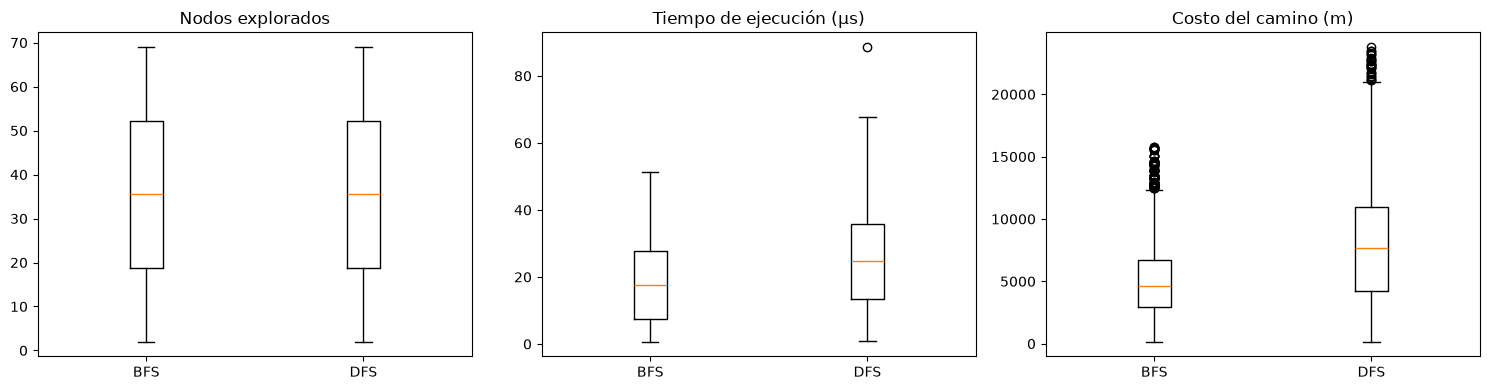

In [19]:
pairs_with_path = {k: v for k, v in all_pairs.items() if v["bfs"]["path"] and v["dfs"]["path"]}

bfs_nodes_explored = [v["bfs"]["nodes_explored"] for v in pairs_with_path.values()]
dfs_nodes_explored = [v["dfs"]["nodes_explored"] for v in pairs_with_path.values()]
bfs_times = [v["bfs"]["time_s"] for v in pairs_with_path.values()]
dfs_times = [v["dfs"]["time_s"] for v in pairs_with_path.values()]
bfs_costs = [v["bfs"]["cost"] for v in pairs_with_path.values()]
dfs_costs = [v["dfs"]["cost"] for v in pairs_with_path.values()]

bfs_better = sum(1 for b, d in zip(bfs_costs, dfs_costs) if b < d)
dfs_better = sum(1 for b, d in zip(bfs_costs, dfs_costs) if d < b)
tie = sum(1 for b, d in zip(bfs_costs, dfs_costs) if abs(b - d) < 1e-6)

print("=== Comparación agregada (todos los pares) ===")
print(f"Nodos explorados  - BFS promedio: {sum(bfs_nodes_explored)/len(bfs_nodes_explored):.1f}  |  "
      f"DFS promedio: {sum(dfs_nodes_explored)/len(dfs_nodes_explored):.1f}")
print(f"Tiempo (us)        - BFS promedio: {sum(bfs_times)/len(bfs_times)*1e6:.1f}  |  "
      f"DFS promedio: {sum(dfs_times)/len(dfs_times)*1e6:.1f}")
print(f"Costo camino (m)   - BFS promedio: {sum(bfs_costs)/len(bfs_costs):.0f}  |  "
      f"DFS promedio: {sum(dfs_costs)/len(dfs_costs):.0f}")
print(f"BFS con menor costo que DFS: {bfs_better} pares | DFS con menor costo: {dfs_better} | empate: {tie}")

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].boxplot([bfs_nodes_explored, dfs_nodes_explored], tick_labels=["BFS", "DFS"])
axes[0].set_title("Nodos explorados")
axes[1].boxplot([[t*1e6 for t in bfs_times], [t*1e6 for t in dfs_times]], tick_labels=["BFS", "DFS"])
axes[1].set_title("Tiempo de ejecución (µs)")
axes[2].boxplot([bfs_costs, dfs_costs], tick_labels=["BFS", "DFS"])
axes[2].set_title("Costo del camino (m)")
plt.tight_layout()
plt.show()

## 7. Exportación de datos para la visualización interactiva (Leaflet)

Se exportan nodos, aristas (con su polilínea real) y las trazas BFS/DFS de todos los pares a `data/graph_export.json` y a `viz/graph_data.js` (mismo contenido embebido como variable JS, para que la página Leaflet funcione con solo abrir el archivo, sin servidor). El camino final se dibuja en la demo siguiendo la calle real trazada, no una línea recta entre nodos.

In [20]:
export_nodes = [
    {
        "id": nid,
        "name": d["name"],
        "lat": d["lat"],
        "lon": d["lon"],
        "role": "deposito" if nid == DEPOSITO_ID else ("cliente_ejemplo" if nid == CLIENTE_ID else "normal"),
    }
    for nid, d in G.nodes(data=True)
]
def _oriented_points(a, pts):
    # networkx (undirected graph) may report an edge's (a, b) in either order,
    # regardless of which node the points polyline actually starts at — realign
    # the points to start at `a` so source/target always match the geometry.
    if not pts:
        return pts
    a_lat, a_lon = G.nodes[a]["lat"], G.nodes[a]["lon"]
    first_lat, first_lon = pts[0]
    if abs(first_lat - a_lat) > 1e-9 or abs(first_lon - a_lon) > 1e-9:
        return list(reversed(pts))
    return pts


export_edges = [
    {"source": a, "target": b, "weight": d["weight"], "points": _oriented_points(a, d["points"])}
    for a, b, d in G.edges(data=True)
]
export_pairs = {
    key: {
        "bfs": {"order": v["bfs"]["order"], "path": v["bfs"]["path"], "cost": v["bfs"]["cost"],
                "nodes_explored": v["bfs"]["nodes_explored"], "time_s": v["bfs"]["time_s"]},
        "dfs": {"order": v["dfs"]["order"], "path": v["dfs"]["path"], "cost": v["dfs"]["cost"],
                "nodes_explored": v["dfs"]["nodes_explored"], "time_s": v["dfs"]["time_s"]},
    }
    for key, v in all_pairs.items()
}

_center_lat = sum(n["lat"] for n in export_nodes) / len(export_nodes)
_center_lon = sum(n["lon"] for n in export_nodes) / len(export_nodes)

export = {
    "center": {"lat": _center_lat, "lon": _center_lon},
    "deposito_id": DEPOSITO_ID,
    "cliente_id": CLIENTE_ID,
    "nodes": export_nodes,
    "edges": export_edges,
    "pairs": export_pairs,
}

json_path = os.path.join("..", "data", "graph_export.json")
js_path = os.path.join("..", "viz", "graph_data.js")

with open(json_path, "w", encoding="utf-8") as f:
    json.dump(export, f, ensure_ascii=False)

with open(js_path, "w", encoding="utf-8") as f:
    f.write("const GRAPH_DATA = ")
    json.dump(export, f, ensure_ascii=False)
    f.write(";\n")

print("Exportado:", json_path)
print("Exportado:", js_path)
print("Tamaño JSON:", os.path.getsize(json_path), "bytes")

Exportado: ..\data\graph_export.json
Exportado: ..\viz\graph_data.js
Tamaño JSON: 4094486 bytes
